# INVERTER CIRCUIT 32nm bulk CMOS

> Dataset source repository: https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction
> Dataset Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

<small>

I'm using simu_0/treated_data dataset in this analysis

**Joined_data.csv:** contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

**Treated_data.csv:** contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algorithms usa o joined_data e depois gera o treated_data.

*No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0.*

</small>

# MLP Training and tuning

In [1]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
import pandas as pd
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.neural_network import MLPRegressor

I0000 00:00:1780269150.134322   88488 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780269150.137187   88488 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780269150.383999   88488 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780269151.491376   88488 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
import joblib

# Loading scalers
scaler_x = joblib.load('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/scaler_x.pkl')
scaler_y = joblib.load('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/scaler_y.pkl')

# Loading split data

X_train_sc = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_train_sc.csv')
X_val_sc   = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_val_sc.csv')
Xte_sc     = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_test_sc.csv')

y_train_sc = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_train_sc.csv')
y_val_sc   = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_val_sc.csv')
yte_sc     = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_test_sc.csv')

print(f"Training set loaded: {X_train_sc.shape}")
print(f"Validation set loaded: {X_val_sc.shape}")
print(f"Test set loaded: {Xte_sc.shape}")

Training set loaded: (64204, 7)
Validation set loaded: (31624, 7)
Test set loaded: (31943, 7)


In [3]:
#plots_dir = "/home/eduarda/Repos/jupyter_ic/figures/CMOS/32nm/NOT/05_mlp_training_tuning"

# test grid search
plots_dir = "/home/eduarda/Repos/jupyter_ic/figures/CMOS/32nm/NOT/05_mlp_training_tuning/grid_search_tuning_test"

In [4]:
save_models_dir = '/home/eduarda/Repos/jupyter_ic/models/trained/MLP_Regressor/CMOS/32nm/NOT/single_output/grid_search_tuning_test'

**Loading MLP Models**

In [5]:
# Path
scikitL_model = '/home/eduarda/Repos/jupyter_ic/models/untrained/mlp_regressor_SKL_untrained.joblib'

In [6]:
# Loading Scikit-Learn models
scikitL_model_SingleOut_32nm_cmos = joblib.load(scikitL_model)
mlp_regressor = joblib.load(scikitL_model)

## Score functions

In [7]:
scores = {}

In [8]:
def score(model, X, y, target_name, target_variable, target_set):
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    rmse = root_mean_squared_error(y, pred)
    mse = mean_squared_error(y, pred)

    scores[target_name, target_variable, target_set] = {
        'r2': r2,
        'rmse': rmse,
        'mse': mse,
    }
    return scores[target_name, target_variable, target_set]

**Grid search**
FOR TPHL

In [9]:
TECH = "CMOS 32 nm"
LOGIC_GATE = "NOT"
TARGET_VARIABLE ="TPHL"

In [10]:
# 1. Juntamos o conjunto de Treino e Validação (já que o scikit-learn gerenciará os folds internamente)
X = pd.concat([X_train_sc, X_val_sc], axis=0, ignore_index=True)
y_completo = pd.concat([y_train_sc, y_val_sc], axis=0, ignore_index=True)

y = y_completo['tphl']

print(f"\nDados unificados prontos para a Otimização (Grid + 10-Fold CV):")
print(f"X formato final: {X.shape}")
print(f"y formato final: {y.shape}")


Dados unificados prontos para a Otimização (Grid + 10-Fold CV):
X formato final: (95828, 7)
y formato final: (95828,)


In [ ]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (500, 100)],
    'learning_rate_init': [0.001, 0.01,]
}

In [12]:
grid = GridSearchCV(estimator=mlp_regressor, param_grid=param_grid, scoring='r2', cv=3, n_jobs=-1)

In [13]:
# Training
grid.fit(X_train_sc, y_train_sc['tphl'])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [14]:
melhores_parametros = grid.best_params_
print(f"-> Best params: {melhores_parametros}\n")

-> Best params: {'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}



In [15]:
# --- 10-FOLD CROSS-VALIDATION ---
print("10-FOLD CROSS-VALIDATION")
mlp_otimizada = MLPRegressor(
    activation='relu',
    solver='adam',
    max_iter=500,
    shuffle=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    early_stopping=True,
    random_state=42,
    verbose=False,
    hidden_layer_sizes=melhores_parametros['hidden_layer_sizes'],
    learning_rate_init=melhores_parametros['learning_rate_init']
)

metricas = {
    'r2': 'r2', 
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error'
}
resultados_cv = cross_validate(mlp_otimizada, X, y, cv=10, scoring=metricas)

r2_m, r2_s = resultados_cv['test_r2'].mean(), resultados_cv['test_r2'].std()
mse_m, mse_s = -resultados_cv['test_mse'].mean(), resultados_cv['test_mse'].std()
rmse_m, rmse_s = -resultados_cv['test_rmse'].mean(), resultados_cv['test_rmse'].std()

linhas_tabela = [{
    'Technology': TECH,
    'Gate': LOGIC_GATE,
    'Variable': TARGET_VARIABLE,
    'Hidden Layers': str(melhores_parametros['hidden_layer_sizes']),
    'Learning Rate': melhores_parametros['learning_rate_init'],
    'R² Score': f"{r2_m:f} (± {r2_s:f})",
    'MSE': f"{mse_m:f} (± {mse_s:f})", 
    'RMSE': f"{rmse_m:f} (± {rmse_s:f})"
}]

df_final = pd.DataFrame(linhas_tabela)
df_final.set_index(['Technology', 'Gate', 'Variable'], inplace=True)

print("\n" + "="*25 + " RESULTS " + "="*25)
print(df_final)

10-FOLD CROSS-VALIDATION

========================= RESULTS =========================
                         Hidden Layers  Learning Rate               R² Score  \
Technology Gate Variable                                                       
CMOS 32 nm NOT  TPHL          (50, 50)           0.01  0.999675 (± 0.000072)   

                                            MSE                   RMSE  
Technology Gate Variable                                                
CMOS 32 nm NOT  TPHL      0.000326 (± 0.000074)  0.017947 (± 0.002020)  


**Grid search**
FOR TPLH

In [16]:
TECH = "CMOS 32 nm"
LOGIC_GATE = "NOT"
TARGET_VARIABLE ="TPLH"

In [17]:
mlp_regressor = clone(mlp_regressor)

In [18]:
# --- AJUSTE DO DATASET PARA O GRID SEARCH / CROSS-VALIDATION ---

# 1. Juntamos o conjunto de Treino e Validação (já que o scikit-learn gerenciará os folds internamente)
X = pd.concat([X_train_sc, X_val_sc], axis=0, ignore_index=True)
y_completo = pd.concat([y_train_sc, y_val_sc], axis=0, ignore_index=True)

# 2. Extraímos apenas a variável alvo que você quer estudar neste momento (tphl)
y = y_completo['tplh']

print(f"\nDados unificados prontos para a Otimização (Grid + 10-Fold CV):")
print(f"X formato final: {X.shape}")
print(f"y formato final: {y.shape}")


Dados unificados prontos para a Otimização (Grid + 10-Fold CV):
X formato final: (95828, 7)
y formato final: (95828,)


In [20]:
print(f"Rodando Grid Search para {TECH} | {LOGIC_GATE} | {TARGET_VARIABLE}...")

Rodando Grid Search para CMOS 32 nm | NOT | TPLH...


In [21]:
grid = GridSearchCV(estimator=mlp_regressor, param_grid=param_grid, scoring='r2', cv=3, n_jobs=-1)

In [22]:
# Training
grid.fit(X_train_sc, y_train_sc['tplh'])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [23]:
melhores_parametros = grid.best_params_
print(f"-> Melhores parâmetros encontrados: {melhores_parametros}\n")

-> Melhores parâmetros encontrados: {'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}



In [24]:
# --- 4. PASSO 2: 10-FOLD CROSS-VALIDATION (Validação Científica) ---
print("Iniciando Validação Cruzada de 10 folds com o modelo otimizado...")
mlp_otimizada = MLPRegressor(
    activation='relu',
    solver='adam',
    max_iter=500,
    shuffle=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    early_stopping=True,
    random_state=42,
    verbose=False,
    hidden_layer_sizes=melhores_parametros['hidden_layer_sizes'],
    learning_rate_init=melhores_parametros['learning_rate_init']
)

# Otimização: Adicionado o 'neg_root_mean_squared_error' do próprio scikit-learn
metricas = {
    'r2': 'r2', 
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error'
}
resultados_cv = cross_validate(mlp_otimizada, X, y, cv=10, scoring=metricas)

# Extração direta e inversão dos sinais negativos das métricas de erro do sklearn
r2_m, r2_s = resultados_cv['test_r2'].mean(), resultados_cv['test_r2'].std()
mse_m, mse_s = -resultados_cv['test_mse'].mean(), resultados_cv['test_mse'].std()
rmse_m, rmse_s = -resultados_cv['test_rmse'].mean(), resultados_cv['test_rmse'].std()

# --- 5. PASSO 3: GERAR E EXIBIR A TABELA DE RESULTADOS ---
# Otimização: Criamos strings limpas combinando a Média (± Desvio Padrão) em formato decimal pleno {:f}
linhas_tabela = [{
    'Technology': TECH,
    'Gate': LOGIC_GATE,
    'Variable': TARGET_VARIABLE,
    'Hidden Layers': str(melhores_parametros['hidden_layer_sizes']),
    'Learning Rate': melhores_parametros['learning_rate_init'],
    'R² Score': f"{r2_m:f} (± {r2_s:f})",
    'MSE': f"{mse_m:f} (± {mse_s:f})", 
    'RMSE': f"{rmse_m:f} (± {rmse_s:f})"
}]

df_final = pd.DataFrame(linhas_tabela)
df_final.set_index(['Technology', 'Gate', 'Variable'], inplace=True)

print("\n" + "="*25 + " RESULTADO DO DATASET " + "="*25)
print(df_final)

Iniciando Validação Cruzada de 10 folds com o modelo otimizado...


/home/eduarda/Repos/jupyter_ic/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")



========================= RESULTADO DO DATASET =========================
                         Hidden Layers  Learning Rate               R² Score  \
Technology Gate Variable                                                       
CMOS 32 nm NOT  TPLH         (100, 50)          0.001  0.999352 (± 0.000034)   

                                            MSE                   RMSE  
Technology Gate Variable                                                
CMOS 32 nm NOT  TPLH      0.000643 (± 0.000034)  0.025342 (± 0.000660)  


**Grid search**
FOR ENERGY

In [ ]:
TECH = "CMOS 32 nm"
LOGIC_GATE = "NOT"
TARGET_VARIABLE ="TPLH"

In [ ]:
mlp_regressor = clone(mlp_regressor)

In [ ]:
# --- AJUSTE DO DATASET PARA O GRID SEARCH / CROSS-VALIDATION ---

# 1. Juntamos o conjunto de Treino e Validação (já que o scikit-learn gerenciará os folds internamente)
X = pd.concat([X_train_sc, X_val_sc], axis=0, ignore_index=True)
y_completo = pd.concat([y_train_sc, y_val_sc], axis=0, ignore_index=True)

# 2. Extraímos apenas a variável alvo que você quer estudar neste momento (tphl)
y = y_completo['energy']

print(f"\nDados unificados prontos para a Otimização (Grid + 10-Fold CV):")
print(f"X formato final: {X.shape}")
print(f"y formato final: {y.shape}")


Dados unificados prontos para a Otimização (Grid + 10-Fold CV):
X formato final: (95828, 7)
y formato final: (95828,)


In [ ]:
grid = GridSearchCV(estimator=mlp_regressor, param_grid=param_grid, scoring='r2', cv=3, n_jobs=-1)

In [ ]:
# Training
grid.fit(X_train_sc, y_train_sc['energy'])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPRegressor(...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'hidden_layer_sizes': [(50,), (100,), ...], 'learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [ ]:
melhores_parametros = grid.best_params_
print(f"-> Melhores parâmetros encontrados: {melhores_parametros}\n")

-> Melhores parâmetros encontrados: {'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001}



In [ ]:
# --- 4. PASSO 2: 10-FOLD CROSS-VALIDATION (Validação Científica) ---
print("Iniciando Validação Cruzada de 10 folds com o modelo otimizado...")
mlp_otimizada = MLPRegressor(
    activation='relu',
    solver='adam',
    max_iter=500,
    shuffle=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    early_stopping=True,
    random_state=42,
    verbose=False,
    hidden_layer_sizes=melhores_parametros['hidden_layer_sizes'],
    learning_rate_init=melhores_parametros['learning_rate_init']
)

# Otimização: Adicionado o 'neg_root_mean_squared_error' do próprio scikit-learn
metricas = {
    'r2': 'r2', 
    'mse': 'neg_mean_squared_error',
    'rmse': 'neg_root_mean_squared_error'
}
resultados_cv = cross_validate(mlp_otimizada, X, y, cv=10, scoring=metricas)

# Extração direta e inversão dos sinais negativos das métricas de erro do sklearn
r2_m, r2_s = resultados_cv['test_r2'].mean(), resultados_cv['test_r2'].std()
mse_m, mse_s = -resultados_cv['test_mse'].mean(), resultados_cv['test_mse'].std()
rmse_m, rmse_s = -resultados_cv['test_rmse'].mean(), resultados_cv['test_rmse'].std()

# --- 5. PASSO 3: GERAR E EXIBIR A TABELA DE RESULTADOS ---
# Otimização: Criamos strings limpas combinando a Média (± Desvio Padrão) em formato decimal pleno {:f}
linhas_tabela = [{
    'Technology': TECH,
    'Gate': LOGIC_GATE,
    'Variable': TARGET_VARIABLE,
    'Hidden Layers': str(melhores_parametros['hidden_layer_sizes']),
    'Learning Rate': melhores_parametros['learning_rate_init'],
    'R² Score': f"{r2_m:f} (± {r2_s:f})",
    'MSE': f"{mse_m:f} (± {mse_s:f})", 
    'RMSE': f"{rmse_m:f} (± {rmse_s:f})"
}]

df_final = pd.DataFrame(linhas_tabela)
df_final.set_index(['Technology', 'Gate', 'Variable'], inplace=True)

print("\n" + "="*25 + " RESULTADO DO DATASET " + "="*25)
print(df_final)

Iniciando Validação Cruzada de 10 folds com o modelo otimizado...

========================= RESULTADO DO DATASET =========================
                         Hidden Layers  Learning Rate               R² Score  \
Technology Gate Variable                                                       
CMOS 32 nm NOT  TPLH         (100, 50)          0.001  0.998525 (± 0.000097)   

                                            MSE                   RMSE  
Technology Gate Variable                                                
CMOS 32 nm NOT  TPLH      0.001474 (± 0.000099)  0.038371 (± 0.001285)  


In [ ]:
print("Executando até aqui...")

raise RuntimeError("Parada forçada")

Executando até aqui...


RuntimeError: Parada forçada

## CMOS

### Single-output models

**SCIKIT-LEARN**

In [ ]:
#### Predicting TPHL

In [ ]:
# Training
scikitL_model_SingleOut_32nm_cmos.fit(X_train_sc, y_train_sc['tphl'])

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [ ]:
print(f"Output activation function: {scikitL_model_SingleOut_32nm_cmos.out_activation_}")
print(f"The current loss computed with the loss function: {scikitL_model_SingleOut_32nm_cmos.loss_}")
print(f"The minimum loss reached by the solver throughout fitting: {scikitL_model_SingleOut_32nm_cmos.best_loss_}")
print(f"The number of iterations the solver has run: {scikitL_model_SingleOut_32nm_cmos.n_iter_}")
print(f"Best R2 score that triggered early_stopping: {scikitL_model_SingleOut_32nm_cmos.best_validation_score_}")
print(f"R2 score: {scikitL_model_SingleOut_32nm_cmos.validation_scores_}")
print(f"Number of output layers: {scikitL_model_SingleOut_32nm_cmos.n_outputs_}")
print(f"Number of layers: {scikitL_model_SingleOut_32nm_cmos.n_layers_}")
print(f"Number of features seen during fit: {scikitL_model_SingleOut_32nm_cmos.n_features_in_}")

Output activation function: identity
The current loss computed with the loss function: 0.00018926437785591525
The minimum loss reached by the solver throughout fitting: None
The number of iterations the solver has run: 25
Best R2 score that triggered early_stopping: 0.9996589789308129
R2 score: [0.9259337986833247, 0.9730764473279728, 0.9886012261352822, 0.9947414592907207, 0.9966273162359287, 0.9972640462468437, 0.9981089765783292, 0.9984812597778062, 0.9987474258182601, 0.9989294806763483, 0.9990975726046089, 0.9992500599374562, 0.999224025063665, 0.9993811483860466, 0.9994106697800305, 0.9994868546598462, 0.9995044790219242, 0.9994981720657383, 0.9995464704726296, 0.9995535467627854, 0.9995425718136098, 0.9996321095540768, 0.9996405122948304, 0.9996589789308129, 0.9996196237569799]
Number of output layers: 1
Number of layers: 3
Number of features seen during fit: 7


In [ ]:
# Validation
y_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(X_val_sc)

In [ ]:
# Validation R² score
scikitL_model_SingleOut_32nm_cmos.score(X_val_sc, y_val_sc['tphl'])

0.9996754255715159

In [ ]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tphl'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(y_val_sc['tphl'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.018045827624443324
clf: MLP, MSE 0.00032565189465112184


In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, X_val_sc, y_val_sc['tphl'], 'mlp_S_SKL', 'tphl', 'val')

{'r2': 0.9996754255715159,
 'rmse': 0.018045827624443324,
 'mse': 0.00032565189465112184}

In [ ]:
# Testing
y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(Xte_sc)

In [ ]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tphl'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(yte_sc['tphl'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.01864515971001044
clf: MLP, MSE 0.00034764198061179667


In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, Xte_sc, yte_sc['tphl'], 'mlp_S_SKL', 'tphl', 'test')

{'r2': 0.9996568242502238,
 'rmse': 0.01864515971001044,
 'mse': 0.00034764198061179667}

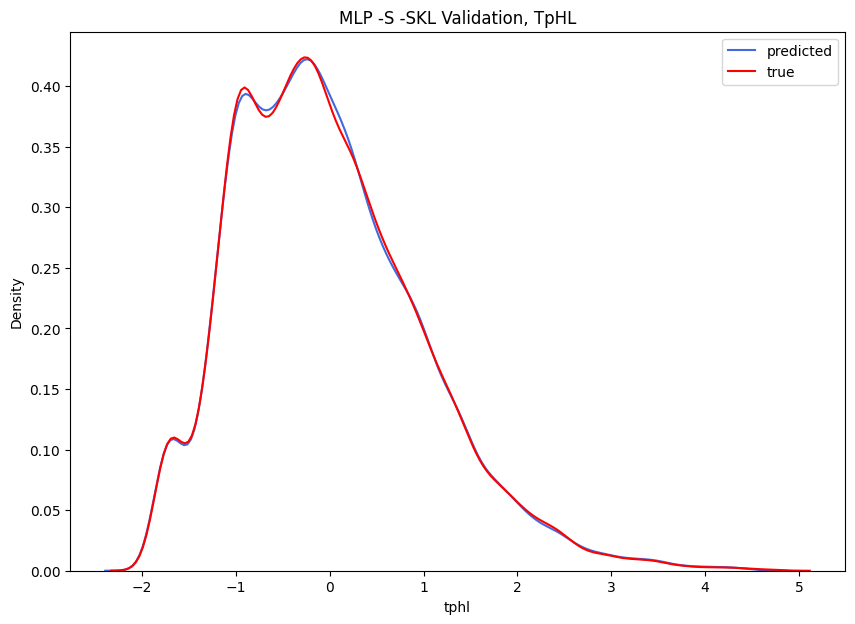

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPHL.png")
plt.show()
plt.close()

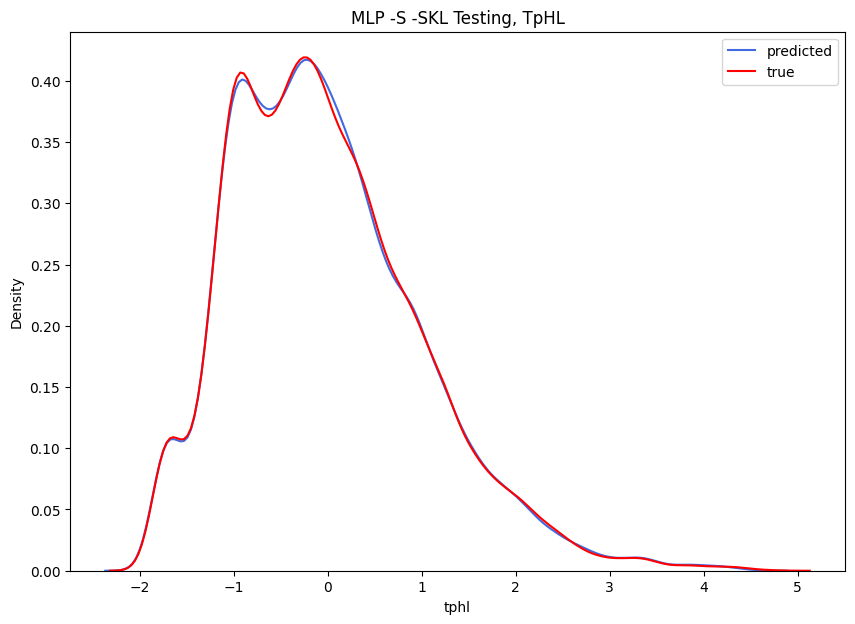

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPHL.png")
plt.show()
plt.close()

In [ ]:
# SAVE TRAINED
# LOAD CLEAN MODEL

In [ ]:
#joblib.dump(scikitL_model_SingleOut_32nm_cmos, "/home/eduarda/Repos/jupyter_ic/models/trained/MLP_Regressor/CMOS/32nm/NOT/single_output/tphl/mlp_regressor_SKL_TRAINED_32nm_TPHL.joblib")
joblib.dump(scikitL_model_SingleOut_32nm_cmos, f"{save_models_dir}/mlp_regressor_SKL_TRAINED_32nm_TPHL.joblib")
print("Modelo treinado salvo com sucesso!")

Modelo treinado salvo com sucesso!


#### Predicting TPLH

In [ ]:
scikitL_model_SingleOut_32nm_cmos = clone(scikitL_model_SingleOut_32nm_cmos)

In [ ]:
# Training
scikitL_model_SingleOut_32nm_cmos.fit(X_train_sc, y_train_sc['tplh'])

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [ ]:
print(f"Output activation function: {scikitL_model_SingleOut_32nm_cmos.out_activation_}")
print(f"The current loss computed with the loss function: {scikitL_model_SingleOut_32nm_cmos.loss_}")
print(f"The minimum loss reached by the solver throughout fitting: {scikitL_model_SingleOut_32nm_cmos.best_loss_}")
print(f"The number of iterations the solver has run: {scikitL_model_SingleOut_32nm_cmos.n_iter_}")
print(f"Best R2 score that triggered early_stopping: {scikitL_model_SingleOut_32nm_cmos.best_validation_score_}")
print(f"R2 score: {scikitL_model_SingleOut_32nm_cmos.validation_scores_}")
print(f"Number of output layers: {scikitL_model_SingleOut_32nm_cmos.n_outputs_}")
print(f"Number of layers: {scikitL_model_SingleOut_32nm_cmos.n_layers_}")
print(f"Number of features seen during fit: {scikitL_model_SingleOut_32nm_cmos.n_features_in_}")

Output activation function: identity
The current loss computed with the loss function: 0.0003663888587580965
The minimum loss reached by the solver throughout fitting: None
The number of iterations the solver has run: 22
Best R2 score that triggered early_stopping: 0.9992871005638386
R2 score: [0.8902698332671051, 0.9643489656195017, 0.9865761978908129, 0.9937738129347637, 0.9962691514456058, 0.997398864289093, 0.9980577002092089, 0.9985083294107905, 0.9988346060885354, 0.9989252305555819, 0.9990272747301974, 0.9990726406585512, 0.9991433655815333, 0.999211541349401, 0.9991832125885897, 0.9992346503890187, 0.9992709677257039, 0.9992715958822816, 0.9992282763796264, 0.9992197425214611, 0.9992871005638386, 0.9992868193709777]
Number of output layers: 1
Number of layers: 3
Number of features seen during fit: 7


In [ ]:
# Validation
y_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(X_val_sc)

In [ ]:
# Validation R² score
scikitL_model_SingleOut_32nm_cmos.score(X_val_sc, y_val_sc['tplh'])

0.9992730086252184

In [ ]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tplh'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(y_val_sc['tplh'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.026609033490751256
clf: MLP, MSE 0.000708040663311922


In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, X_val_sc, y_val_sc['tplh'], 'mlp_S_SKL', 'tplh', 'val')

{'r2': 0.9992730086252184,
 'rmse': 0.026609033490751256,
 'mse': 0.000708040663311922}

In [ ]:
# Testing
y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(Xte_sc)

In [ ]:
# Testing R² score
scikitL_model_SingleOut_32nm_cmos.score(Xte_sc, yte_sc['tplh'])

0.9992687983939565

In [ ]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tplh'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(yte_sc['tplh'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.027004031564189256
clf: MLP, MSE 0.0007292177207197296


In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, Xte_sc, yte_sc['tplh'], 'mlp_S_SKL', 'tplh', 'test')

{'r2': 0.9992687983939565,
 'rmse': 0.027004031564189256,
 'mse': 0.0007292177207197296}

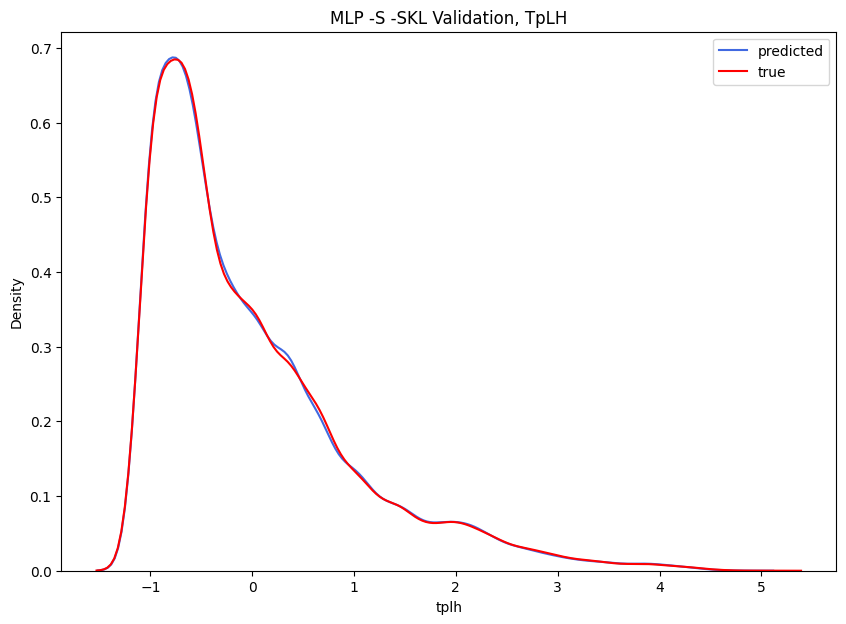

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpLH')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPLH.png")
plt.show()
plt.close()

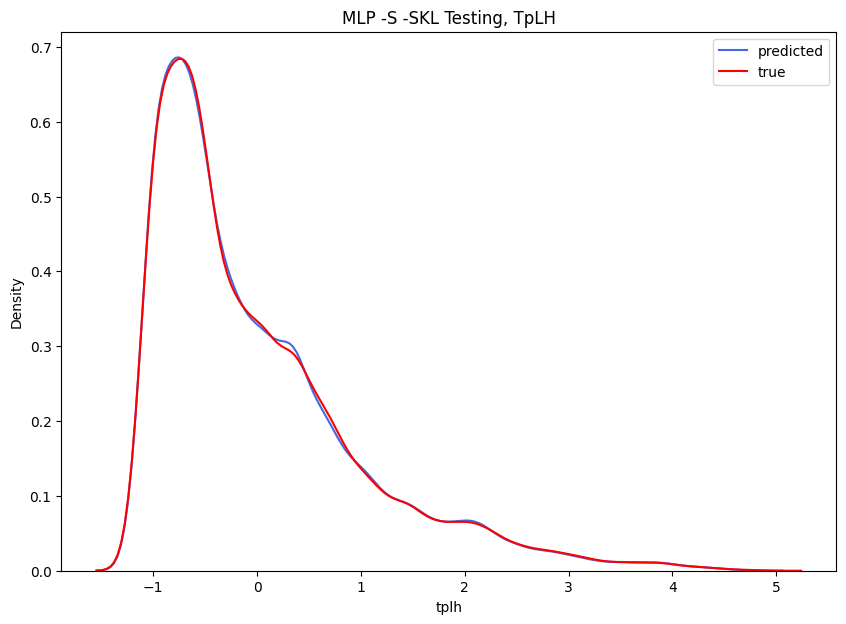

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpLH')
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPLH.png")
ax.legend()
plt.show()
plt.close()

In [ ]:
#joblib.dump(scikitL_model_SingleOut_32nm_cmos, "/home/eduarda/Repos/jupyter_ic/models/trained/MLP_Regressor/CMOS/32nm/NOT/single_output/tplh/mlp_regressor_SKL_TRAINED_32nm_TPLH.joblib")
joblib.dump(scikitL_model_SingleOut_32nm_cmos, f"{save_models_dir}/mlp_regressor_SKL_TRAINED_32nm_TPLH.joblib")
print("Modelo treinado salvo com sucesso!")

Modelo treinado salvo com sucesso!


In [ ]:
#### Predicting Energy

In [ ]:
scikitL_model_SingleOut_32nm_cmos = clone(scikitL_model_SingleOut_32nm_cmos)

In [ ]:
# Training
scikitL_model_SingleOut_32nm_cmos.fit(X_train_sc, y_train_sc['energy'])

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [ ]:

print(f"Output activation function: {scikitL_model_SingleOut_32nm_cmos.out_activation_}")
print(f"The current loss computed with the loss function: {scikitL_model_SingleOut_32nm_cmos.loss_}")
print(f"The minimum loss reached by the solver throughout fitting: {scikitL_model_SingleOut_32nm_cmos.best_loss_}")
print(f"The number of iterations the solver has run: {scikitL_model_SingleOut_32nm_cmos.n_iter_}")
print(f"Best R2 score that triggered early_stopping: {scikitL_model_SingleOut_32nm_cmos.best_validation_score_}")
print(f"R2 score: {scikitL_model_SingleOut_32nm_cmos.validation_scores_}")
print(f"Number of output layers: {scikitL_model_SingleOut_32nm_cmos.n_outputs_}")
print(f"Number of layers: {scikitL_model_SingleOut_32nm_cmos.n_layers_}")
print(f"Number of features seen during fit: {scikitL_model_SingleOut_32nm_cmos.n_features_in_}")

Output activation function: identity
The current loss computed with the loss function: 0.0009347708717357155
The minimum loss reached by the solver throughout fitting: None
The number of iterations the solver has run: 26
Best R2 score that triggered early_stopping: 0.9981925646265903
R2 score: [0.909373480406904, 0.9709001436204846, 0.9860489796217242, 0.9915367439850413, 0.9938646040306783, 0.9951832409227326, 0.9956763744941618, 0.9963613303467463, 0.9967679262881193, 0.9970483498929579, 0.9971865247668997, 0.9973316834056578, 0.9975443342313525, 0.9976159073715529, 0.9977912898745238, 0.9978459247741525, 0.9977249051364261, 0.9979330398757673, 0.9980304222825396, 0.9980354973956519, 0.9979385115602644, 0.9980139271553276, 0.9980558961938363, 0.9980683791951144, 0.9981400843676289, 0.9981925646265903]
Number of output layers: 1
Number of layers: 3
Number of features seen during fit: 7


In [ ]:
# Validation
y_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(X_val_sc)

In [ ]:
# Validation R² score
scikitL_model_SingleOut_32nm_cmos.score(X_val_sc, y_val_sc['energy'])

0.9981770230257411

In [ ]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['energy'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(y_val_sc['energy'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.04266864027693507
clf: MLP, MSE 0.0018206128630824862


In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, X_val_sc, y_val_sc['energy'], 'mlp_S_SKL', 'energy', 'val')

{'r2': 0.9981770230257411,
 'rmse': 0.04266864027693507,
 'mse': 0.0018206128630824862}

In [ ]:
# Testing
y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(Xte_sc)

In [ ]:
# Testing R² score
scikitL_model_SingleOut_32nm_cmos.score(Xte_sc, yte_sc['energy'])

0.9981936869983989

In [ ]:
# Testing error
rmse = root_mean_squared_error(yte_sc['energy'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(yte_sc['energy'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.04258214838798362
clf: MLP, MSE 0.001813239361336256


In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, Xte_sc, yte_sc['energy'], 'mlp_S_SKL', 'energy', 'test')

{'r2': 0.9981936869983989,
 'rmse': 0.04258214838798362,
 'mse': 0.001813239361336256}

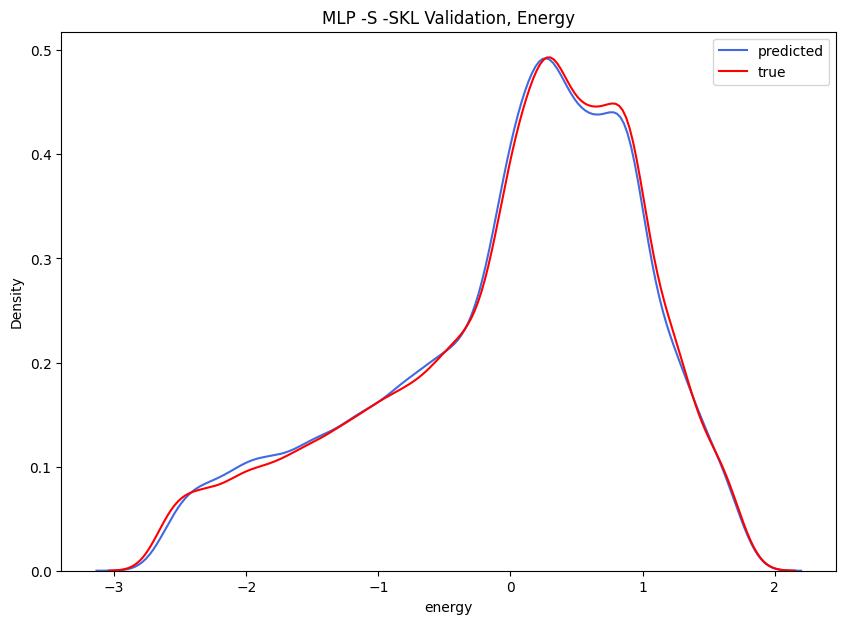

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['energy'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, Energy')
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_Energy.png")
ax.legend()
plt.show()
plt.close()

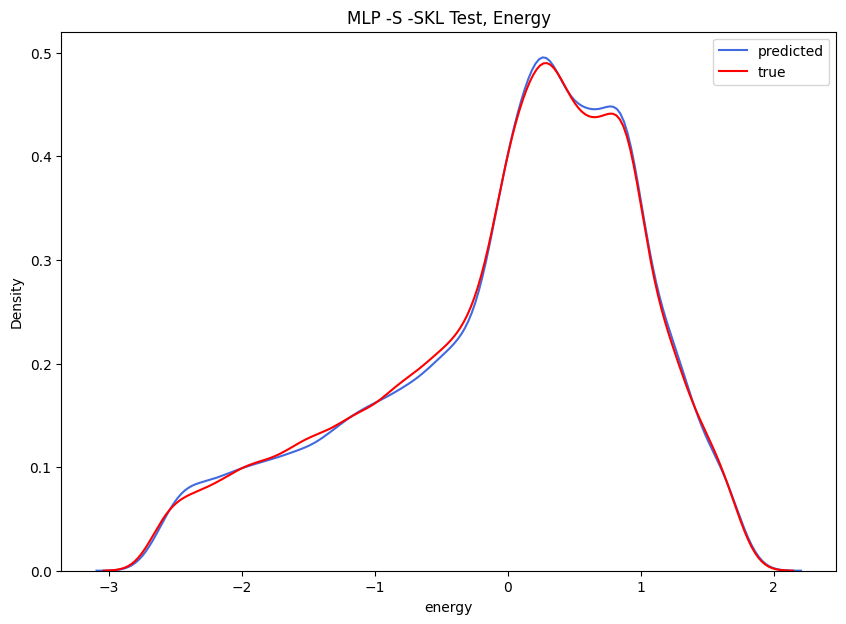

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['energy'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Test, Energy')
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_Energy.png")
ax.legend()
plt.show()
plt.close()

In [ ]:
#joblib.dump(scikitL_model_SingleOut_32nm_cmos, "/home/eduarda/Repos/jupyter_ic/models/trained/MLP_Regressor/CMOS/32nm/NOT/single_output/energy/mlp_regressor_SKL_TRAINED_32nm_ENERGY.joblib")
joblib.dump(scikitL_model_SingleOut_32nm_cmos, f"{save_models_dir}/mlp_regressor_SKL_TRAINED_32nm_ENERGY.joblib")
print("Modelo treinado salvo com sucesso!")

Modelo treinado salvo com sucesso!


In [ ]:
import os
results = pd.DataFrame.from_dict(scores, orient='index')
results.index.names = ['target', 'model', 'set']
#path = os.path.join('/home/eduarda/Repos/jupyter_ic/outputs/CMOS/32nm/NOT/MLP_Regressor/SKL/single_output', 'results_singleout_mlps')

path = os.path.join('/home/eduarda/Repos/jupyter_ic/outputs/CMOS/32nm/NOT/MLP_Regressor/SKL/single_output/grid_search_tuning_test', 'grid_search_singleout_mlps')
from datetime import datetime
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
path_with_time = f"{path}_{current_time}.csv"
results.to_csv(path_with_time, index_label='target_name')

results

r2      rmse       mse
target    model  set                               
mlp_S_SKL tphl   val   0.999675  0.018046  0.000326
                 test  0.999657  0.018645  0.000348
          tplh   val   0.999273  0.026609  0.000708
                 test  0.999269  0.027004  0.000729
          energy val   0.998177  0.042669  0.001821
                 test  0.998194  0.042582  0.001813